# Solitones
Son ondas localiczadas que se propaga  sin cambiar su forma debido a un balance entre:
- **Dispersión** (ensanchamiento)
- **No linealidad** (compresión)

Su aplicación en fibras ópticas permiten la transmisión de información sin distorción a largas distancias, permitiendo pulsoso estables en láseres.

La ecuación KdV
$$\frac{\partial u}{\partial t} + \epsilon u\frac{\partial u}{\partial x} + \mu\frac{\partial^3 u}{\partial x^3} = 0$$
Discretizando:
$$u_{i}^{n+1} = u_i^{n-1}-\frac{\epsilon\Delta t}{3\Delta x}(u_{i+1}^n + u_i^n}n_{i-1}^n)(u_{i+1}^n-u_{i-1}^n)$$

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [7]:
%matplotlib widget
N = 300
dx = 0.4
dt = 0.1
eps = 0.2
mu = 0.1

x = np.arange(N) * dx
u_new = np.zeros(N)
u = 0.5 * (1 - np.tanh(x / 5 - 5))
u_old = u.copy()

"""
fig, ax = plt.subplots()
line, = ax.plot(x, u)
ax.set_ylim(-0.2, 1.2)

def update(frame):
    global u, u_old, u_new

    for i in range(2, N - 2):
        nonlinear = (u[i + 1] + u[i] + u[i - 1]) * (u[i + 1] - u[i - 1])
        dispersion = (u[i + 2] + 2 * u[i - 1] - 2 * u[i + 1]- u[i - 2])

        u_new[i] = (u_old[i] - eps * dt / (3 * dx) * nonlinear - mu * dt / (dx ** 3) * dispersion)
        
    u_old = u.copy()
    u = u_new.copy()

    line.set_ydata(u)
    return line,

ani = FuncAnimation(fig, update, frames = 300)

plt.show()
"""

'\nfig, ax = plt.subplots()\nline, = ax.plot(x, u)\nax.set_ylim(-0.2, 1.2)\n\ndef update(frame):\n    global u, u_old, u_new\n\n    for i in range(2, N - 2):\n        nonlinear = (u[i + 1] + u[i] + u[i - 1]) * (u[i + 1] - u[i - 1])\n        dispersion = (u[i + 2] + 2 * u[i - 1] - 2 * u[i + 1]- u[i - 2])\n\n        u_new[i] = (u_old[i] - eps * dt / (3 * dx) * nonlinear - mu * dt / (dx ** 3) * dispersion)\n\n    u_old = u.copy()\n    u = u_new.copy()\n\n    line.set_ydata(u)\n    return line,\n\nani = FuncAnimation(fig, update, frames = 300)\n\nplt.show()\n'

# Pulso Gaussiano

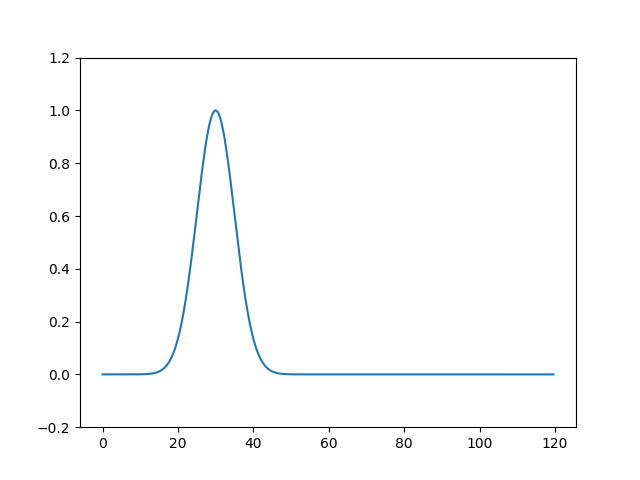

In [27]:
x = np.arange(N) * dx

u = np.exp(-(x - 30) ** 2 / 50)
u_old = u.copy()
u_new = np.zeros_like(u)

fig, ax = plt.subplots()
line, = ax.plot(x, u)
ax.set_ylim(-0.2, 1.2)

def update(frame):
    global u, u_old, u_new

    for i in range(2, N - 2):
        nonlinear = (u[i + 1] + u[i] + u[i - 1]) * (u[i + 1] - u[i - 1])
        dispersion = (u[i + 2] + 2 * u[i - 1] - 2 * u[i + 1]- u[i - 2])

        u_new[i] = (u_old[i] - eps * dt / (3 * dx) * nonlinear - mu * dt / (dx ** 3) * dispersion)
        
    u_old = u.copy()
    u = u_new.copy()

    line.set_ydata(u)
    return line,

ani = FuncAnimation(fig, update, frames = 300)


# Dos pulsos

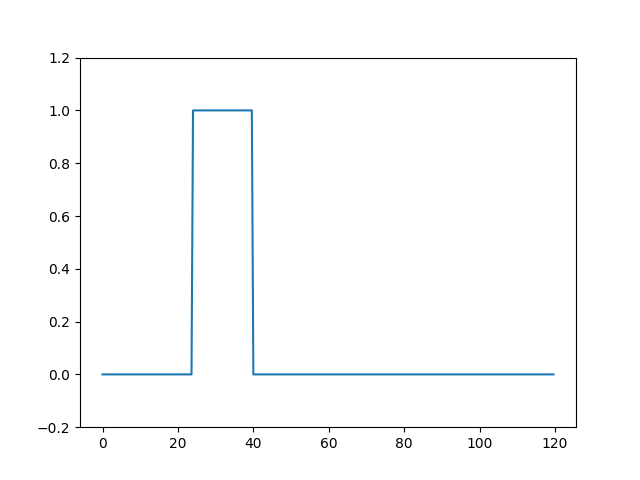

In [5]:
x = np.arange(N) * dx

u = np.zeros_like(x)
u[60:100] = 1 #np.exp(-(x - 20) ** 2 / 40) + 0.5 * np.exp(- (x - 60) ** 2 / 40)
u_old = u.copy()
u_new = np.zeros_like(u)

fig, ax = plt.subplots()
line, = ax.plot(x, u)
ax.set_ylim(-0.2, 1.2)

def update(frame):
    global u, u_old, u_new

    for i in range(2, N - 2):
        nonlinear = (u[i + 1] + u[i] + u[i - 1]) * (u[i + 1] - u[i - 1])
        dispersion = (u[i + 2] + 2 * u[i - 1] - 2 * u[i + 1]- u[i - 2])

        u_new[i] = (u_old[i] - eps * dt / (3 * dx) * nonlinear - mu * dt / (dx ** 3) * dispersion)
        
    u_old = u.copy()
    u = u_new.copy()

    line.set_ydata(u)
    return line,

ani = FuncAnimation(fig, update, frames = 300)


Velocidad:
$$v \propto A$$

Velocidad estimada del pulso: 1.4154


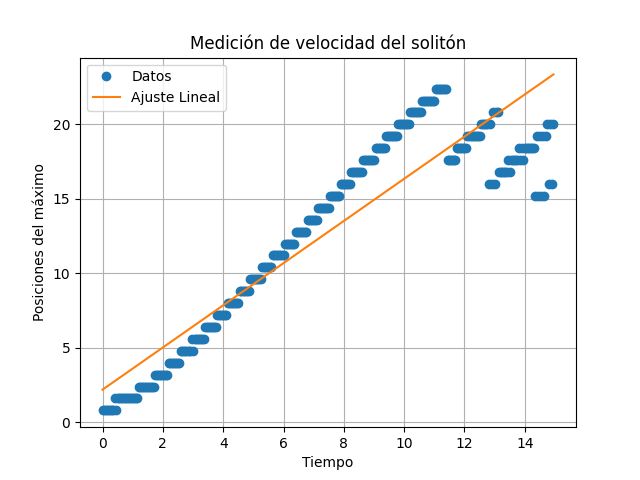

In [10]:
N = 300
dx = 0.4
dt = 0.05
eps = 0.2
mu = 0.1
Nt = 300

x = np.arange(N) * dx

u = 0.5 * (1 - np.tanh(x / 5 - 5))

u_old = u.copy()
u_new = np.zeros_like(u)

posiciones = []
tiempos = []
for n in range(Nt):
    for i in range(2, N - 2):
        nonlinear = (u[i + 1] + u[i] + u[i - 1]) * (u[i + 1] - u[i - 1])
        dispersion = (u[i + 2] + 2 * u[i - 1] - 2 * u[i + 1]- u[i - 2])

        u_new[i] = (u_old[i] - eps * dt / (3 * dx) * nonlinear - mu * dt / (dx ** 3) * dispersion)
        
    u_old = u.copy()
    u = u_new.copy()

    x_max = x[np.argmax(u)]

    posiciones.append(x_max)
    tiempos.append(n * dt)


#Ajuste lineal

coef = np.polyfit(tiempos, posiciones, 1)
velocidad = coef[0]

print(f"Velocidad estimada del pulso: {velocidad:.4f}")

plt.figure()
plt.plot(tiempos, posiciones, 'o', label = "Datos")
plt.plot(tiempos, np.polyval(coef, tiempos), '-', label = "Ajuste Lineal")
plt.xlabel("Tiempo")
plt.ylabel("Posiciones del máximo")
plt.title("Medición de velocidad del solitón")
plt.legend()
plt.grid()
plt.show()

# Random

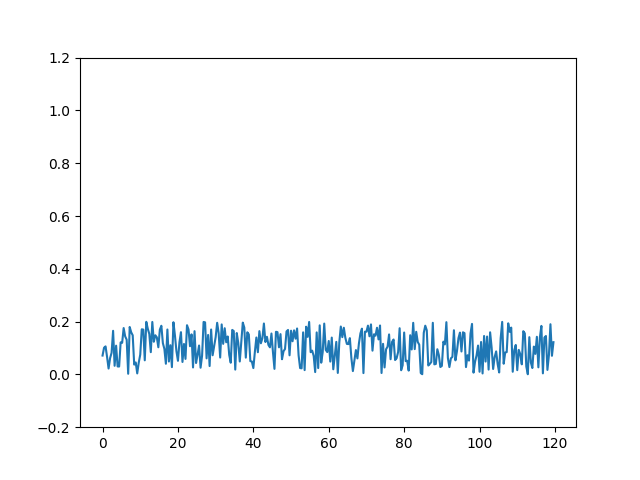

In [13]:
x = np.arange(N) * dx

u = 0.2 * np.random.rand(N) #np.exp(-(x - 20) ** 2 / 40) + 0.5 * np.exp(- (x - 60) ** 2 / 40)
u_old = u.copy()
u_new = np.zeros_like(u)

fig, ax = plt.subplots()
line, = ax.plot(x, u)
ax.set_ylim(-0.2, 1.2)

def update(frame):
    global u, u_old, u_new

    for i in range(2, N - 2):
        nonlinear = (u[i + 1] + u[i] + u[i - 1]) * (u[i + 1] - u[i - 1])
        dispersion = (u[i + 2] + 2 * u[i - 1] - 2 * u[i + 1]- u[i - 2])

        u_new[i] = (u_old[i] - eps * dt / (3 * dx) * nonlinear - mu * dt / (dx ** 3) * dispersion)
        
    u_old = u.copy()
    u = u_new.copy()

    line.set_ydata(u)
    return line,

ani = FuncAnimation(fig, update, frames = 50)